In [1]:
#Airline dataset task using matplotlib(DV).

!pip install matplotlib
!pip install pandas
!pip install numpy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("AirlineDataset.csv")
data

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,10856,Edithe,Leggis,Female,62.0,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,43872,Elwood,Catt,Male,62.0,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,42633,Darby,Felgate,Male,67.0,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,78493,Dominica,Pyle,Female,71.0,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,82072,Bay,Pencost,Male,21.0,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90695,80393,Heath,Losano,Female,87.0,Poland,Bar River Airport,CA,Canada,NAM,North America,5/9/2022,YEB,Heath Losano,Cancelled
90696,15482,Pauletta,Sima,Female,20.0,Indonesia,Cooperstown-Westville Airport,US,United States,NAM,North America,2/24/2022,COP,Pauletta Sima,Cancelled
90697,65380,Alberto,McRill,Male,3.0,China,Ouagadougou Airport,BF,Burkina Faso,AF,Africa,11/12/2022,OUA,Alberto McRill,Cancelled
90698,12020,Ingaborg,Gothrup,Female,76.0,Indonesia,Wondai Airport,AU,Australia,OC,Oceania,8/20/2022,WDI,Ingaborg Gothrup,Delayed


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90700 entries, 0 to 90699
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Passenger ID          90700 non-null  int64  
 1   First Name            90699 non-null  object 
 2   Last Name             90699 non-null  object 
 3   Gender                90699 non-null  object 
 4   Age                   90699 non-null  float64
 5   Nationality           90699 non-null  object 
 6   Airport Name          90699 non-null  object 
 7   Airport Country Code  90699 non-null  object 
 8   Country Name          90699 non-null  object 
 9   Airport Continent     90699 non-null  object 
 10  Continents            90699 non-null  object 
 11  Departure Date        90699 non-null  object 
 12  Arrival Airport       90699 non-null  object 
 13  Pilot Name            90699 non-null  object 
 14  Flight Status         90699 non-null  object 
dtypes: float64(1), int6

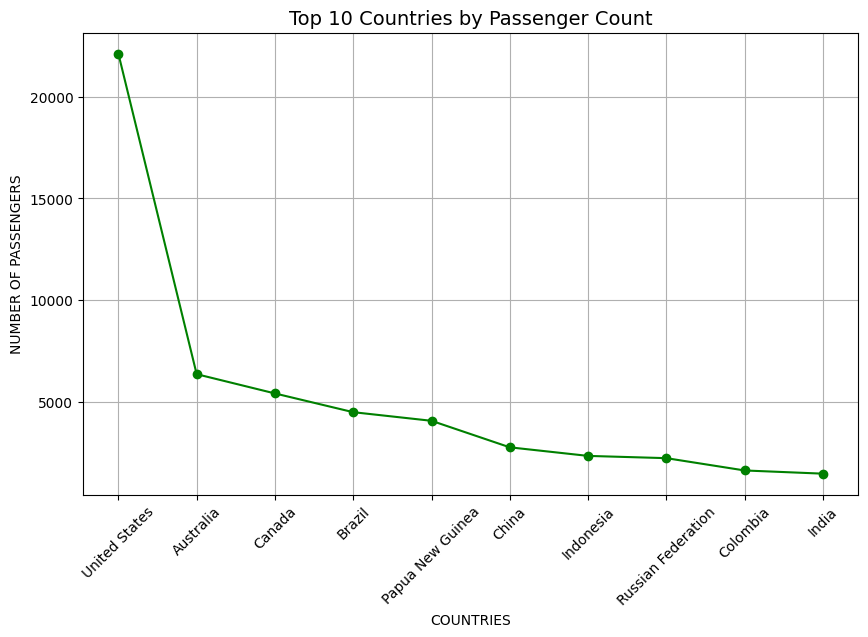

In [4]:
data = pd.read_csv("AirlineDataset.csv")
country_count = data["Country Name"].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.plot(country_count.index, country_count.values, marker='o', linestyle='-', color='green')
plt.title("Top 10 Countries by Passenger Count", fontsize=14)
plt.xlabel("COUNTRIES")
plt.ylabel("NUMBER OF PASSENGERS")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

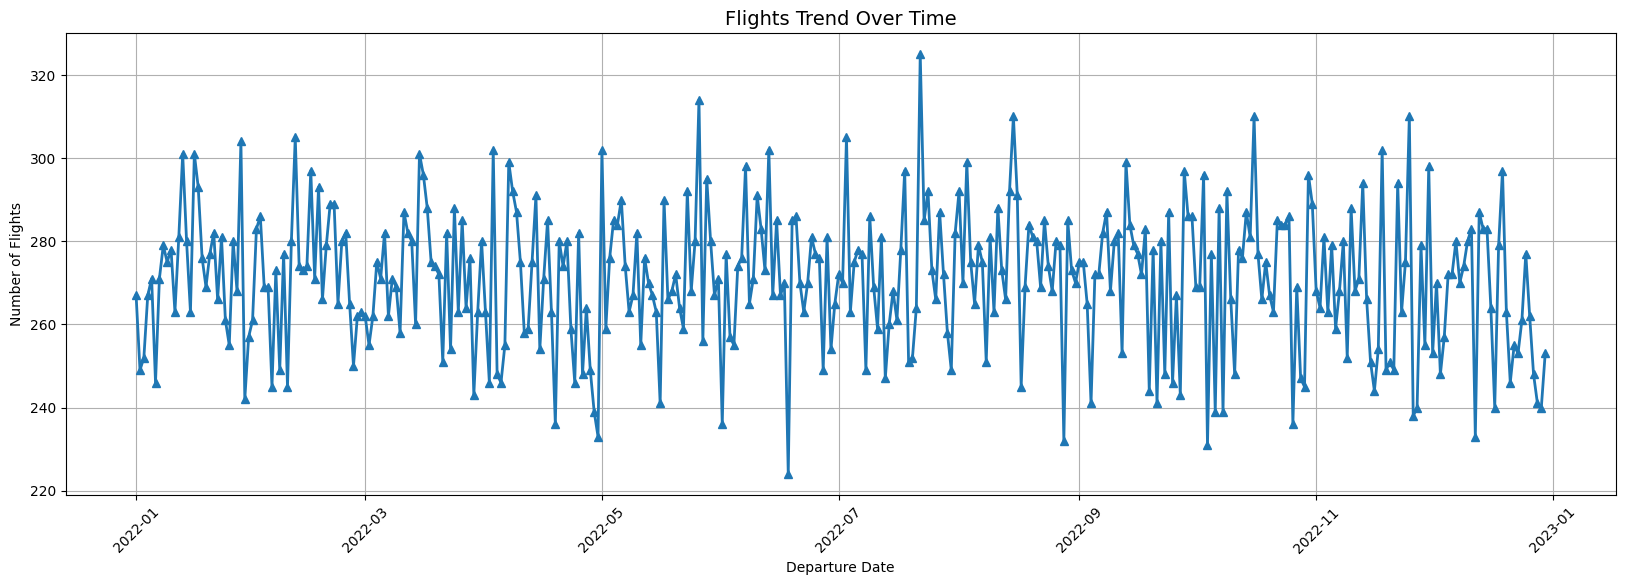

In [5]:
data["Departure Date"] = pd.to_datetime(data["Departure Date"], errors='coerce')
flights_per_day = data["Departure Date"].value_counts().sort_index()
plt.figure(figsize=(20,6))
plt.plot(flights_per_day.index, flights_per_day.values, marker='^', linewidth=2)
plt.title("Flights Trend Over Time", fontsize=14)
plt.xlabel("Departure Date")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


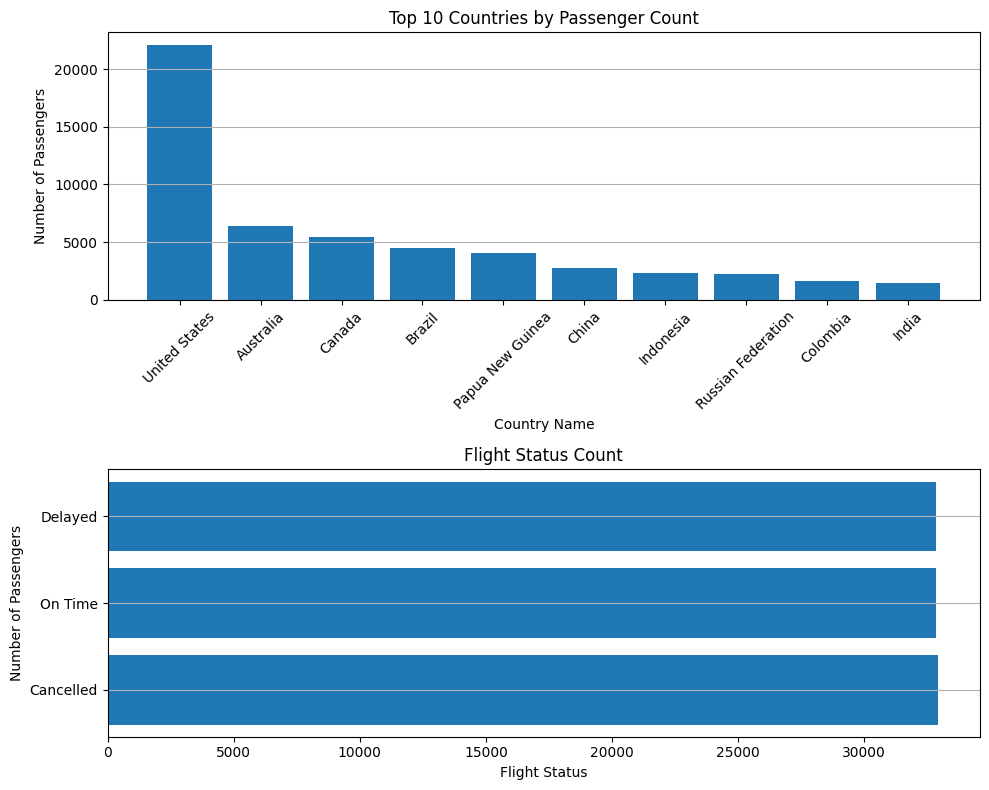

In [6]:
country_count = data["Country Name"].value_counts().head(10)
status_count = data["Flight Status"].value_counts()
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(country_count.index, country_count.values)
axes[0].set_title("Top 10 Countries by Passenger Count", fontsize=12)
axes[0].set_xlabel("Country Name")
axes[0].set_ylabel("Number of Passengers")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y')
axes[1].barh(status_count.index, status_count.values)
axes[1].set_title("Flight Status Count", fontsize=12)
axes[1].set_xlabel("Flight Status")
axes[1].set_ylabel("Number of Passengers")
axes[1].grid(True, axis='y')
plt.tight_layout()
plt.show()

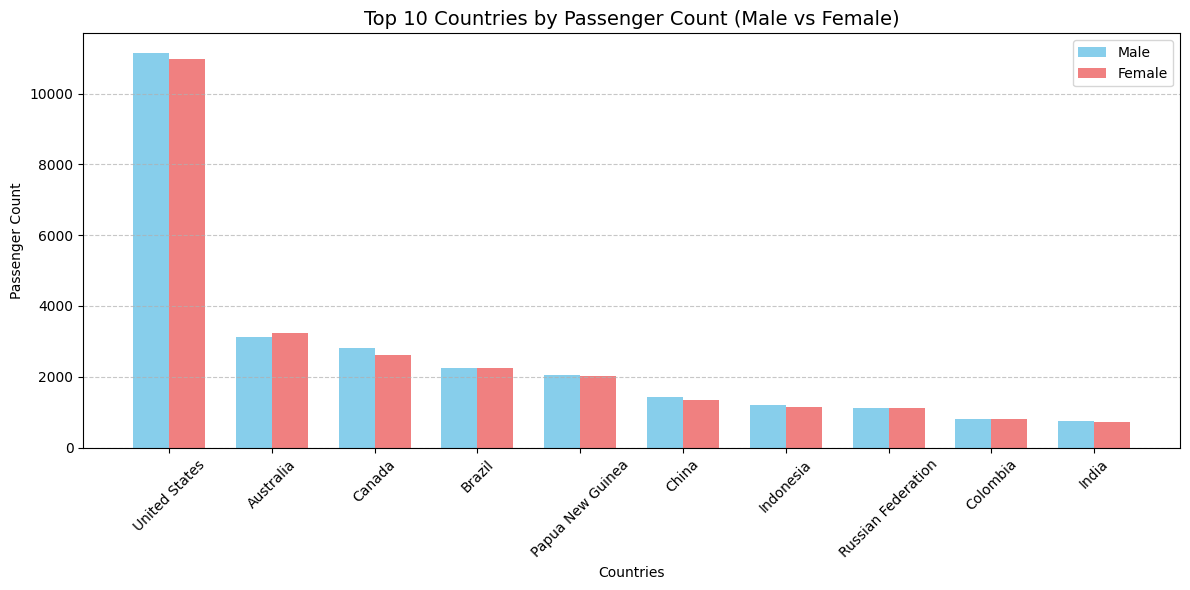

In [7]:
gender_country = data.groupby(["Country Name", "Gender"]).size().unstack(fill_value=0)
top_countries = gender_country.sum(axis=1).nlargest(10).index
gender_country = gender_country.loc[top_countries]
x = np.arange(len(top_countries))
width = 0.35
plt.figure(figsize=(12,6))
plt.bar(x - width/2, gender_country["Male"], width, label="Male", color="skyblue")
plt.bar(x + width/2, gender_country["Female"], width, label="Female", color="lightcoral")

plt.title("Top 10 Countries by Passenger Count (Male vs Female)", fontsize=14)
plt.xlabel("Countries")
plt.ylabel("Passenger Count")
plt.xticks(x, top_countries, rotation=45)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

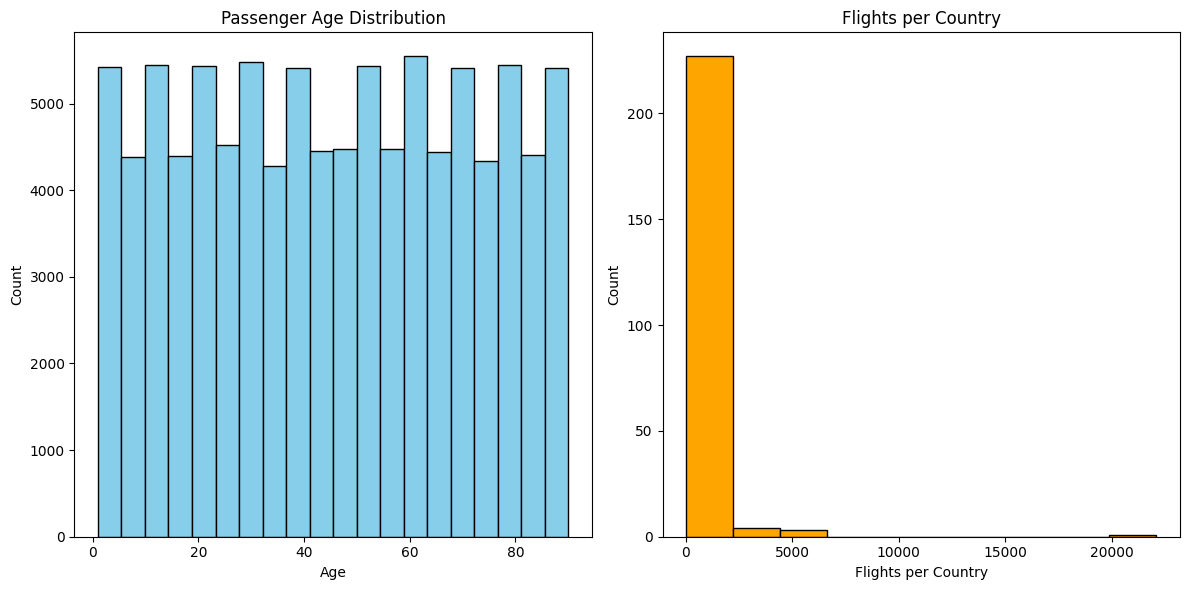

In [8]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(data["Age"].dropna(), bins=20, edgecolor='black', color='skyblue')
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(data["Country Name"].value_counts().values, bins=10, edgecolor='black', color='orange')
plt.title("Flights per Country")
plt.xlabel("Flights per Country")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

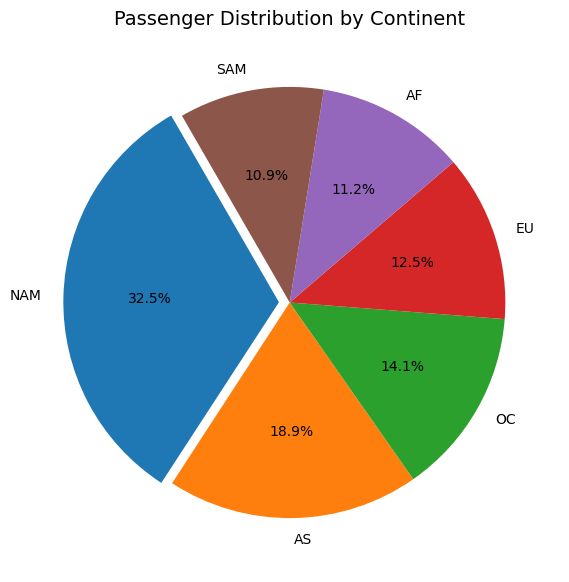

In [16]:
continent_count = data["Airport Continent"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    continent_count,
    labels=continent_count.index,
    autopct="%1.1f%%",
    startangle=120,
    explode=[0.05,0,0,0,0,0]
)

plt.title("Passenger Distribution by Continent", fontsize=14)
plt.show()

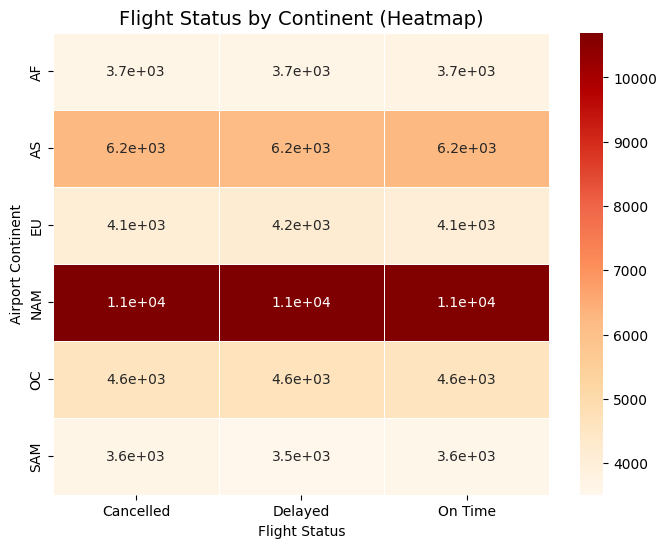

In [10]:
pivot = data.pivot_table(
    index="Airport Continent",
    columns="Flight Status",
    values="Passenger ID",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="OrRd", linewidths=0.5)
plt.title("Flight Status by Continent (Heatmap)", fontsize=14)
plt.show()

In [11]:
data.isnull().sum()

,0
Passenger ID,0
First Name,0
Last Name,0
Gender,0
Age,0
Nationality,0
Airport Name,0
Airport Country Code,0
Country Name,0
Airport Continent,0
